In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Notebook location recommendation:
# Battery_Analysis/notebooks/analyze_stage4_trials.ipynb
PROJECT_ROOT = Path("..")  # Battery_Analysis/
RUN_ROOT = PROJECT_ROOT / "outputs" / "stage4mix_39173858"

RUN_ROOT.exists(), RUN_ROOT


(True, WindowsPath('../outputs/stage4mix_39173858'))

In [2]:
def parse_task_trial(folder_name: str):
    m = re.match(r"task_(\d+)_trial_(\d+)$", folder_name)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))

def infer_mode_from_path(p: Path):
    # expects .../stage4mix_XXXX/{mode}/task_.../stage4_trials.csv
    parts = [x.lower() for x in p.parts]
    for m in ("real", "synth_free", "synth_locked"):
        if m in parts:
            return m
    return "unknown"


In [3]:
def load_all_stage4_trials(run_root: Path) -> pd.DataFrame:
    rows = []
    csv_paths = list(run_root.rglob("stage4_trials.csv"))
    print("Found stage4_trials.csv files:", len(csv_paths))

    for csv_path in csv_paths:
        mode = infer_mode_from_path(csv_path)
        run_folder = csv_path.parent  # task_XX_trial_YY
        task, trial = parse_task_trial(run_folder.name)

        # if structure differs, walk up to find task/trial
        if task is None:
            for p in run_folder.parents:
                task, trial = parse_task_trial(p.name)
                if task is not None:
                    break

        try:
            df = pd.read_csv(csv_path)
            df["mode"] = mode
            df["task"] = task
            df["run_trial"] = trial  # avoid name clash with df["trial"]
            df["run_folder"] = run_folder.name
            df["source_csv"] = str(csv_path)
            rows.append(df)
        except Exception as e:
            print("[warn] failed reading:", csv_path, "err:", repr(e))

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    return out

df = load_all_stage4_trials(RUN_ROOT)
df.shape, df.head()


Found stage4_trials.csv files: 150


((1650, 26),
    trial  x0trial  ok_run   pre_max  post_max       mse      wall_s  err  \
 0      0       12       1  0.965071  0.138339  0.001148  454.524962  NaN   
 1      0       15       1  1.052367  0.167038  0.004329  417.356017  NaN   
 2      0        5       1  1.130847  0.235661  0.008316  403.524474  NaN   
 3      0        8       1  1.942623  0.243148  0.008881  377.777548  NaN   
 4      0        0       1  1.179586  0.266278  0.010689  403.768494  NaN   
 
         xn0       xp0  ...           sDp       sDe        gn           gp  \
 0  0.329218  0.487252  ...  3.242802e-04  1.286221  0.019804  2931.737896   
 1  0.339682  0.584870  ...  1.087956e-30  0.968817  0.013793  1910.857107   
 2  0.161855  0.653562  ...  7.286057e-05  0.838915  1.033268  1309.557931   
 3  0.932752  0.666988  ...  1.678549e-04  0.834212  1.144530  1272.393299   
 4  0.052465  0.821664  ...  8.197305e-04  0.762006  0.929006  1277.443281   
 
          ge  mode  task  run_trial      run_folder  

In [4]:
if len(df) == 0:
    raise RuntimeError("No stage4_trials.csv loaded. Check RUN_ROOT path.")

# Ensure required columns exist
required = {"ok_run", "mse", "post_max"}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Missing expected columns in stage4_trials.csv: {missing}")

# normalize types
df["ok_run"] = pd.to_numeric(df["ok_run"], errors="coerce").fillna(0).astype(int)
df["mse"] = pd.to_numeric(df["mse"], errors="coerce")
df["post_max"] = pd.to_numeric(df["post_max"], errors="coerce")

# optional: remove inf
df = df.replace([np.inf, -np.inf], np.nan)

print("Rows:", len(df))
print("Modes:", df["mode"].value_counts().to_dict())
print("Overall ok_run rate:", df["ok_run"].mean())


Rows: 1650
Modes: {'real': 800, 'synth_free': 800, 'synth_locked': 50}
Overall ok_run rate: 0.6721212121212121


In [5]:
run_keys = ["mode", "task", "run_trial", "run_folder", "source_csv"]

def per_run_stats(df_all: pd.DataFrame) -> pd.DataFrame:
    # successful trials only
    df_succ = df_all[df_all["ok_run"] == 1].copy()

    # per-run metrics
    grp_all = df_all.groupby(run_keys, dropna=False)
    grp_succ = df_succ.groupby(run_keys, dropna=False)

    out = grp_all.agg(
        total_trials=("ok_run", "size"),
        succ_trials=("ok_run", "sum"),
        succ_rate=("ok_run", "mean"),
    ).reset_index()

    # best-of-run (min mse among successful trials)
    best = grp_succ["mse"].min().rename("best_mse").reset_index()

    # median-of-run (median mse among successful trials)
    med = grp_succ["mse"].median().rename("median_mse").reset_index()

    # join
    out = out.merge(best, on=run_keys, how="left").merge(med, on=run_keys, how="left")
    return out

df_run = per_run_stats(df)
df_run.shape, df_run.head()


((150, 10),
    mode  task  run_trial      run_folder  \
 0  real     0          0  task_0_trial_0   
 1  real     1          1  task_1_trial_1   
 2  real     2          2  task_2_trial_2   
 3  real     3          3  task_3_trial_3   
 4  real     4          4  task_4_trial_4   
 
                                           source_csv  total_trials  \
 0  ..\outputs\stage4mix_39173858\real\task_0_tria...            16   
 1  ..\outputs\stage4mix_39173858\real\task_1_tria...            16   
 2  ..\outputs\stage4mix_39173858\real\task_2_tria...            16   
 3  ..\outputs\stage4mix_39173858\real\task_3_tria...            16   
 4  ..\outputs\stage4mix_39173858\real\task_4_tria...            16   
 
    succ_trials  succ_rate  best_mse  median_mse  
 0            8     0.5000  0.001148    0.009785  
 1           11     0.6875  0.001491    0.010245  
 2           10     0.6250  0.001016    0.009362  
 3           10     0.6250  0.001024    0.010735  
 4            9     0.5625  0.001

In [6]:
mode_summary = df_run.groupby("mode").agg(
    runs=("run_folder", "nunique"),
    avg_succ_rate=("succ_rate", "mean"),
    median_succ_rate=("succ_rate", "median"),
    avg_best_mse=("best_mse", "mean"),
    median_best_mse=("best_mse", "median"),
    avg_median_mse=("median_mse", "mean"),
    median_median_mse=("median_mse", "median"),
).sort_values("median_best_mse", ascending=True)

mode_summary


,runs,avg_succ_rate,median_succ_rate,avg_best_mse,median_best_mse,avg_median_mse,median_median_mse
mode,,,,,,,
synth_locked,50,1.00000,1.0000,2.982723e-09,8.384355e-10,2.982723e-09,8.384355e-10
synth_free,50,0.68500,0.6875,8.827381e-09,6.817559e-09,4.181487e-08,4.116197e-08
real,50,0.63875,0.6250,1.859250e-03,1.035737e-03,1.034593e-02,1.063722e-02


In [7]:
df_run_sorted = df_run.sort_values(["best_mse", "median_mse"], ascending=True)
df_run_sorted.head(10)


,mode,task,run_trial,run_folder,source_csv,total_trials,succ_trials,succ_rate,best_mse,median_mse
128,synth_locked,78,28,task_78_trial_28,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,6.214560e-10,6.214560e-10
137,synth_locked,87,37,task_87_trial_37,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,6.221510e-10,6.221510e-10
101,synth_locked,51,1,task_51_trial_1,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,6.411853e-10,6.411853e-10
142,synth_locked,92,42,task_92_trial_42,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,6.419873e-10,6.419873e-10
117,synth_locked,67,17,task_67_trial_17,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,6.432458e-10,6.432458e-10
121,synth_locked,71,21,task_71_trial_21,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,6.721707e-10,6.721707e-10
141,synth_locked,91,41,task_91_trial_41,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,6.727687e-10,6.727687e-10
111,synth_locked,61,11,task_61_trial_11,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,6.809006e-10,6.809006e-10
135,synth_locked,85,35,task_85_trial_35,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,7.098927e-10,7.098927e-10
138,synth_locked,88,38,task_88_trial_38,..\outputs\stage4mix_39173858\synth_locked\tas...,1,1,1.0,7.193018e-10,7.193018e-10


In [8]:
best = df_run_sorted.iloc[0]
print("=== GLOBAL BEST RUN ===")
print(best[["mode","task","run_trial","succ_trials","total_trials","succ_rate","best_mse","median_mse"]].to_dict())
print("source:", best["source_csv"])


=== GLOBAL BEST RUN ===
{'mode': 'synth_locked', 'task': 78, 'run_trial': 28, 'succ_trials': 1, 'total_trials': 1, 'succ_rate': 1.0, 'best_mse': 6.214559975353678e-10, 'median_mse': 6.214559975353678e-10}
source: ..\outputs\stage4mix_39173858\synth_locked\task_78_trial_28\stage4_trials.csv


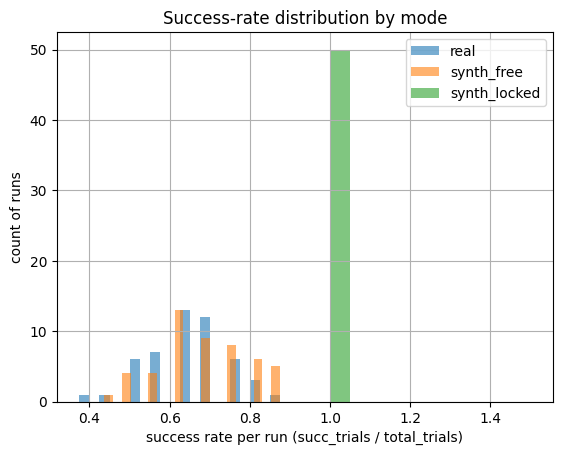

In [9]:
plt.figure()
for mode, g in df_run.groupby("mode"):
    plt.hist(g["succ_rate"].dropna().values, bins=20, alpha=0.6, label=mode)
plt.xlabel("success rate per run (succ_trials / total_trials)")
plt.ylabel("count of runs")
plt.title("Success-rate distribution by mode")
plt.grid(True)
plt.legend()
plt.show()


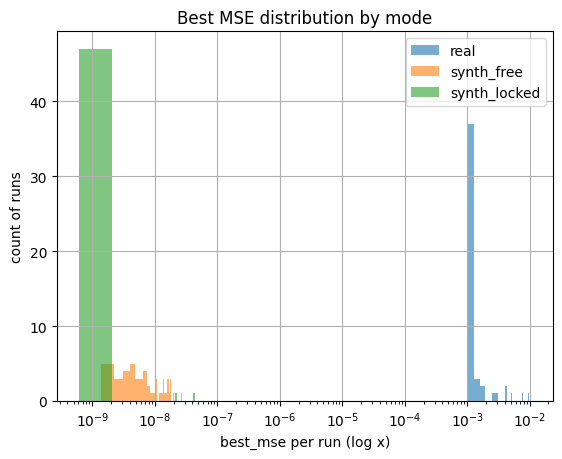

In [10]:
plt.figure()
for mode, g in df_run.groupby("mode"):
    x = g["best_mse"].dropna().values
    plt.hist(x, bins=30, alpha=0.6, label=mode)
plt.xscale("log")
plt.xlabel("best_mse per run (log x)")
plt.ylabel("count of runs")
plt.title("Best MSE distribution by mode")
plt.grid(True)
plt.legend()
plt.show()


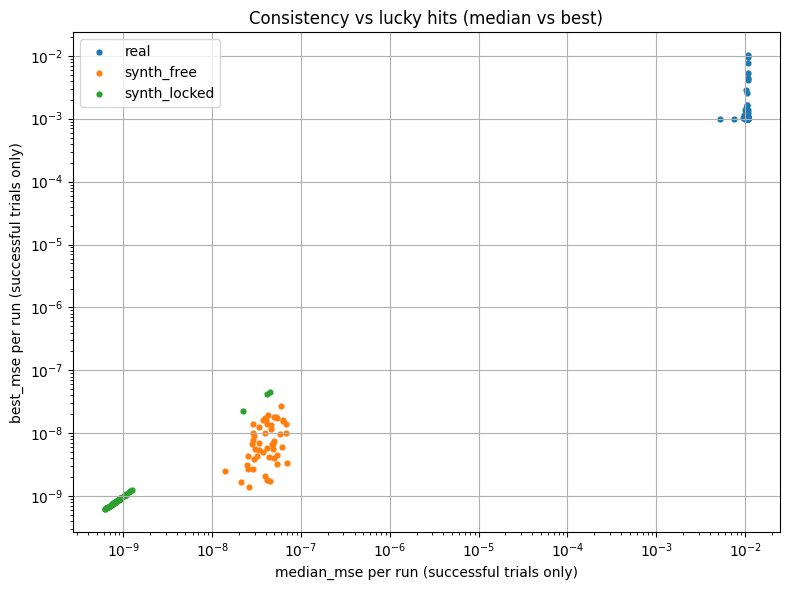

In [11]:
plt.figure(figsize=(8,6))
for mode, g in df_run.groupby("mode"):
    gg = g.dropna(subset=["best_mse", "median_mse"])
    plt.scatter(gg["median_mse"], gg["best_mse"], s=12, label=mode)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("median_mse per run (successful trials only)")
plt.ylabel("best_mse per run (successful trials only)")
plt.title("Consistency vs lucky hits (median vs best)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
